# Relatório Lab 4 — Parte B: Filtragem Espacial Passa-Alta

**Autores:** Allan Hirose Pires de Souza  
**Data de realização dos experimentos:** Março de 2026  
**Data de publicação do relatório:** 10 de Março de 2026  

---

## 1. Introdução

Nesta Parte B do Laboratório 4, trabalhamos com **filtros passa-alta**, que realçam as altas frequências espaciais — bordas, transições abruptas de intensidade e detalhes finos. Em contraste com os filtros passa-baixa, aqui o interesse é justamente nas regiões onde a imagem varia rapidamente.

As técnicas estudadas foram:
- **Filtro Laplaciano** (segunda derivada — detector de bordas omnidirecional)
- **Filtro Sobel** (primeira derivada — detector de bordas direcional)
- **Realce por Laplaciano** — `g(x,y) = f(x,y) + c·∇²f(x,y)`
- **Máscara Unsharp (Highboost Filtering)**
- **Detector de Bordas Canny** (opcional/desafio)

Cada técnica foi aplicada em imagens limpas e em imagens com ruído gaussiano para avaliar a robustez.

---

## 2. Materiais e Métodos

### 2.1 Imagens utilizadas
- **Foto individual de um membro** (`../Lab3/imagem.jpeg`) — convertida para escala de cinza
- **Foto do grupo** (`../Lab3/imagem.jpeg`) — usada também colorida no realce

### 2.2 Parâmetros avaliados
- Laplaciano: `cv2.CV_64F` (preserva negativos)
- Sobel: `ksize = 3` e `ksize = 5`
- Highboost: `k = 1.5` e `k = 3.0`


Imagem individual shape: (470, 1538)


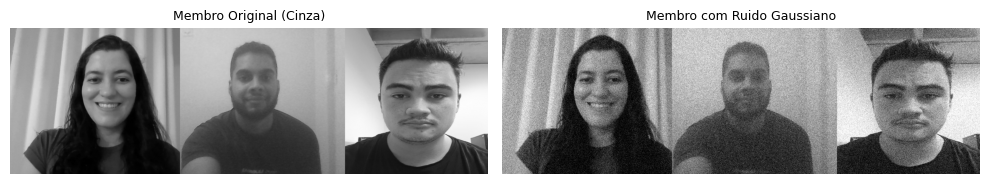

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
import warnings
warnings.filterwarnings('ignore')

# -------------------------------------------------------
# Funcao auxiliar para visualizar imagens lado a lado
# -------------------------------------------------------
def plot_images(images, titles, rows=1, cols=None, figsize=(16, 5), cmap='gray'):
    if cols is None:
        cols = len(images)
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    if rows * cols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img, cmap=cmap)
        ax.set_title(title, fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# -------------------------------------------------------
# Carregamento das imagens
# -------------------------------------------------------
img_membro_bgr   = cv2.imread('../Lab3/imagem.jpeg')
img_grupo_bgr    = cv2.imread('../Lab3/imagem.jpeg')

if img_membro_bgr is None:
    print("[AVISO] imagem.jpeg nao encontrada — usando placeholder")
    img_membro_bgr = np.random.randint(50, 200, (400, 400, 3), dtype=np.uint8)
if img_grupo_bgr is None:
    img_grupo_bgr = img_membro_bgr.copy()

# Versoes em escala de cinza
img_membro     = cv2.cvtColor(img_membro_bgr, cv2.COLOR_BGR2GRAY)
img_grupo_gray = cv2.cvtColor(img_grupo_bgr,  cv2.COLOR_BGR2GRAY)
img_grupo_rgb  = cv2.cvtColor(img_grupo_bgr,  cv2.COLOR_BGR2RGB)

# Imagem com ruido gaussiano para testes de robustez
def adicionar_ruido_gaussiano(imagem, media=0, std=30):
    ruido = np.random.normal(media, std, imagem.shape).astype('float32')
    return np.clip(imagem.astype('float32') + ruido, 0, 255).astype('uint8')

img_membro_ruidosa  = adicionar_ruido_gaussiano(img_membro)
img_grupo_ruidosa   = adicionar_ruido_gaussiano(img_grupo_gray)

print(f"Imagem individual shape: {img_membro.shape}")
plot_images([img_membro, img_membro_ruidosa],
            ['Membro Original (Cinza)', 'Membro com Ruido Gaussiano'],
            figsize=(10, 5))


## 3. Parte B — Item (a): Filtro Laplaciano e Sobel

### 3.1 Laplaciano

O operador Laplaciano (`∇²f`) é a soma das derivadas parciais de segunda ordem em x e em y. Ele é isotrópico (omnidirecional) e muito sensível a variações abruptas de intensidade — e, por isso, também ao ruído.

### 3.2 Sobel

O operador Sobel calcula a magnitude do gradiente (primeira derivada) nas direções x e y separadamente. A combinação `|Gx| + |Gy|` aproxima o gradiente total. É mais robusto que o Laplaciano em presença de ruído.


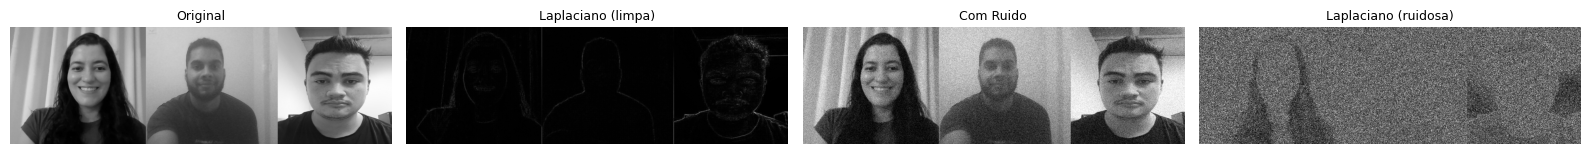

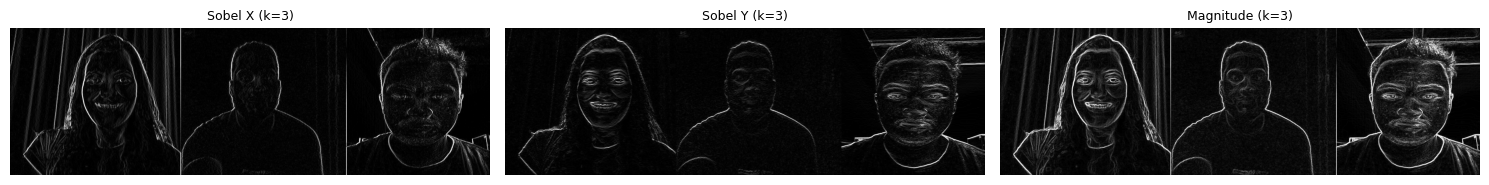

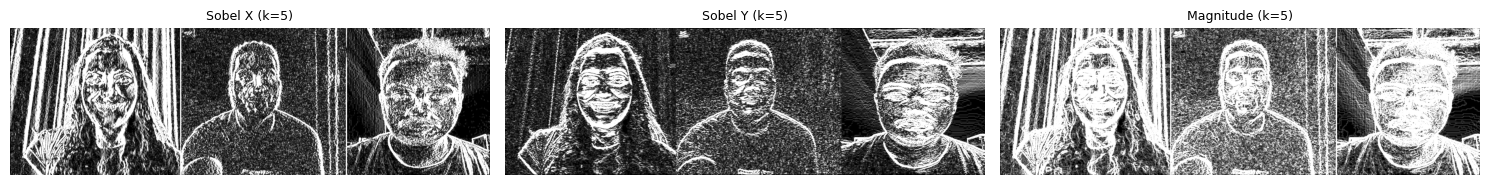

In [2]:
# -------------------------------------------------------
# Laplaciano
# -------------------------------------------------------
laplaciano      = cv2.Laplacian(img_membro, cv2.CV_64F)
laplaciano_abs  = cv2.convertScaleAbs(laplaciano)

laplaciano_ruido     = cv2.Laplacian(img_membro_ruidosa, cv2.CV_64F)
laplaciano_ruido_abs = cv2.convertScaleAbs(laplaciano_ruido)

plot_images(
    [img_membro, laplaciano_abs, img_membro_ruidosa, laplaciano_ruido_abs],
    ['Original', 'Laplaciano (limpa)', 'Com Ruido', 'Laplaciano (ruidosa)'],
    figsize=(16, 5)
)

# -------------------------------------------------------
# Sobel (ksize=3 e ksize=5)
# -------------------------------------------------------
for ksize in [3, 5]:
    sox = cv2.Sobel(img_membro, cv2.CV_64F, 1, 0, ksize=ksize)
    soy = cv2.Sobel(img_membro, cv2.CV_64F, 0, 1, ksize=ksize)
    mag = cv2.convertScaleAbs(np.abs(sox) + np.abs(soy))
    plot_images(
        [cv2.convertScaleAbs(sox), cv2.convertScaleAbs(soy), mag],
        [f'Sobel X (k={ksize})', f'Sobel Y (k={ksize})', f'Magnitude (k={ksize})'],
        figsize=(15, 5)
    )


**Discussão — Laplaciano e Sobel:**

- **Laplaciano:** Detecta bordas em todas as direções simultaneamente. No entanto, é extremamente sensível ao ruído — como mostra a comparação entre a imagem limpa e a ruidosa: o operador amplifica cada pequena variação de intensidade causada pelo ruído.
- **Sobel k=3:** Detecta bordas direcionais (horizontais e verticais) com boa precisão em imagens limpas.
- **Sobel k=5:** Bordas mais espessas e menos suscetíveis a ruídos finos, mas perde detalhes de bordas finas.
- **Diferença direcional:** A separação entre Sobel-X e Sobel-Y é evidente — Sobel-X destaca as bordas verticais e Sobel-Y as horizontais.


## 3. Parte B — Item (b.1): Realce por Laplaciano

A técnica de realce combina a imagem original com o Laplaciano para aumentar a nitidez percebida:

$$g(x, y) = f(x, y) + c \cdot 
abla^2 f(x, y)$$

onde `c = -1` para o Laplaciano positivo no centro (bordas aparecem como vale) ou `c = +1` dependendo da convenção do kernel usado.  
Testamos na imagem limpa e na imagem com ruído gaussiano para avaliar o efeito adverso do ruído no realce.


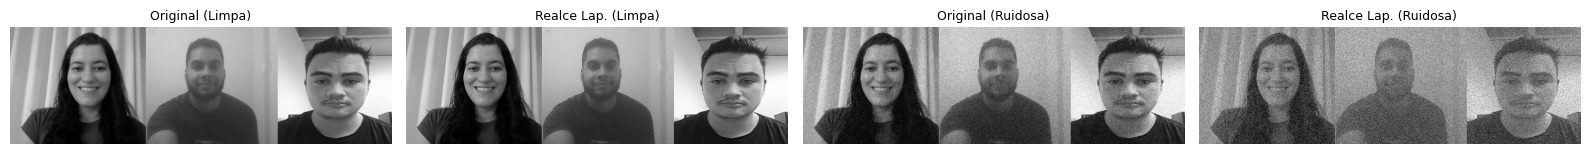

In [3]:
# Realce por Laplaciano: g = f + c * laplaciano
# Utilizando c = -1 (subtrair o laplaciano padrao do OpenCV)

def realce_laplaciano(imagem, c=-1):
    """Aplica realce por laplaciano: g = f + c * L(f)"""
    lap = cv2.Laplacian(imagem, cv2.CV_64F)
    realcada = np.clip(imagem.astype('float64') + c * lap, 0, 255).astype('uint8')
    return realcada

# Imagem limpa
realce_limpa  = realce_laplaciano(img_grupo_gray, c=-1)

# Imagem ruidosa
realce_ruido  = realce_laplaciano(img_grupo_ruidosa, c=-1)

plot_images(
    [img_grupo_gray, realce_limpa, img_grupo_ruidosa, realce_ruido],
    ['Original (Limpa)', 'Realce Lap. (Limpa)', 'Original (Ruidosa)', 'Realce Lap. (Ruidosa)'],
    figsize=(16, 5)
)


**Discussão — Realce por Laplaciano:**

- Na **imagem limpa**, o realce por Laplaciano funcionou como esperado: as bordas e detalhes finos ficaram notavelmente mais nítidos, com c = −1 produzindo um contorno mais pronunciado nas transições de intensidade.
- Na **imagem ruidosa**, o resultado foi adverso: o Laplaciano amplificou o ruído gaussiano junto com as bordas reais, resultando em uma imagem com artefatos visuais intensos. Isso evidencia a **falta de robustez** do realce laplaciano em ambientes ruidosos — antes de aplicar o realce, é recomendável pré-filtrar a imagem com um filtro suavizador.


## 3. Parte B — Item (b.2): Unsharp Masking e Highboost Filtering

A **Máscara Unsharp** é uma técnica clássica de realce que subtrai uma versão borrada da imagem original para criar uma "máscara de detalhe":

$$	ext{máscara} = f(x,y) - ar{f}(x,y)$$

O **Highboost** generaliza a técnica com um fator de amplificação `k`:

$$g(x,y) = f(x,y) + k \cdot 	ext{máscara}$$

- `k = 1`: equivale ao Unsharp Masking padrão
- `k > 1`: aumenta progressivamente o realce


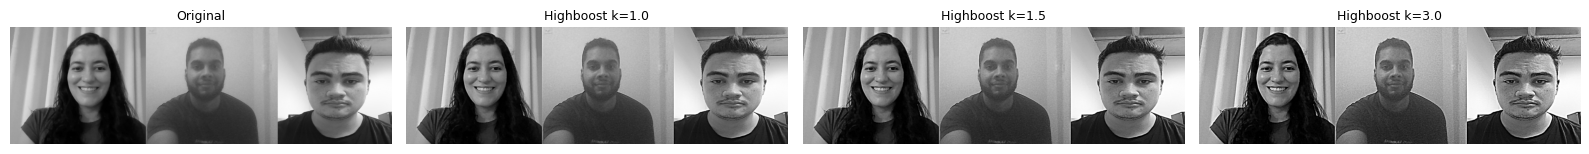

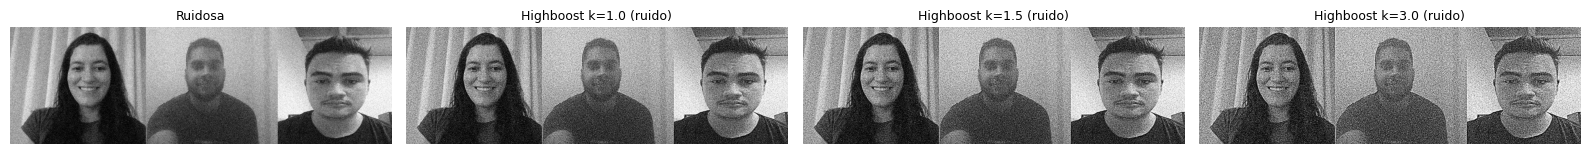

In [4]:
def highboost(imagem, k=1.5, sigma=3):
    """Aplica Highboost Filtering com fator k e suavizacao gaussiana."""
    borrada = cv2.GaussianBlur(imagem, (0, 0), sigma)
    mascara = imagem.astype('float64') - borrada.astype('float64')
    realcada = np.clip(imagem.astype('float64') + k * mascara, 0, 255).astype('uint8')
    return realcada

# Testando diferentes valores de k
ks = [1.0, 1.5, 3.0]
imgs_hb  = [img_grupo_gray] + [highboost(img_grupo_gray, k=ki) for ki in ks]
titulos  = ['Original'] + [f'Highboost k={ki}' for ki in ks]
plot_images(imgs_hb, titulos, figsize=(16, 5))

# Comparacao na imagem ruidosa
imgs_hb_ruido  = [img_grupo_ruidosa] + [highboost(img_grupo_ruidosa, k=ki) for ki in ks]
titulos_ruido  = ['Ruidosa'] + [f'Highboost k={ki} (ruido)' for ki in ks]
plot_images(imgs_hb_ruido, titulos_ruido, figsize=(16, 5))


**Discussão — Highboost Filtering:**

- **k = 1.0 (Unsharp Masking):** O realce é suave e natural. Bordas ficam mais definidas sem artefatos excessivos.
- **k = 1.5:** Realce moderado. Bom equilíbrio entre nitidez e aparência natural.
- **k = 3.0:** Realce agressivo. Bordas ficam muito pronunciadas e começa a aparecer "halos" nas transições de intensidade, um artefato clássico do excesso de realce.
- **Com ruído:** O Highboost amplifica o ruído junto com as bordas, mas o efeito é menos catastrófico que o Laplaciano direto, pois a suavização gaussiana prévia atenua parcialmente o ruído antes de calcular a máscara.


## 3. Parte B — Desafio: Detector de Bordas Canny

O algoritmo de Canny é considerado o estado da arte em detecção de bordas. Diferentemente do Sobel e Laplaciano, ele produz bordas binárias (liga/desliga) de apenas 1 pixel de espessura, com supressão de não-máximos e histerese por dois thresholds.

Comparamos o Canny com o Sobel na imagem limpa e na ruidosa.


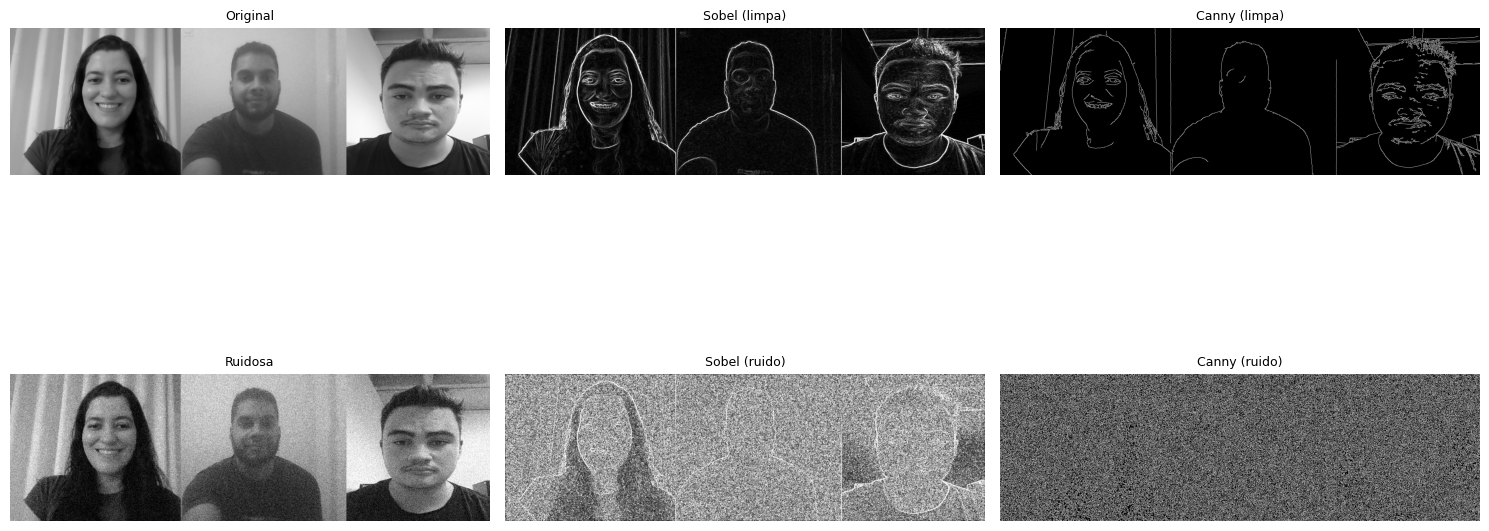

In [5]:
# -------------------------------------------------------
# Canny
# -------------------------------------------------------
canny_limpa  = cv2.Canny(img_membro, threshold1=50, threshold2=150)
canny_ruido  = cv2.Canny(img_membro_ruidosa, threshold1=50, threshold2=150)

# Sobel magnitude para comparacao
sox = cv2.Sobel(img_membro, cv2.CV_64F, 1, 0, ksize=3)
soy = cv2.Sobel(img_membro, cv2.CV_64F, 0, 1, ksize=3)
sobel_mag = cv2.convertScaleAbs(np.abs(sox) + np.abs(soy))

sox_r = cv2.Sobel(img_membro_ruidosa, cv2.CV_64F, 1, 0, ksize=3)
soy_r = cv2.Sobel(img_membro_ruidosa, cv2.CV_64F, 0, 1, ksize=3)
sobel_mag_r = cv2.convertScaleAbs(np.abs(sox_r) + np.abs(soy_r))

plot_images(
    [img_membro,         sobel_mag,    canny_limpa,
     img_membro_ruidosa, sobel_mag_r,  canny_ruido],
    ['Original',         'Sobel (limpa)', 'Canny (limpa)',
     'Ruidosa',          'Sobel (ruido)', 'Canny (ruido)'],
    rows=2, cols=3, figsize=(15, 9)
)


**Discussão — Canny vs Sobel:**

- **Imagem limpa:** O Canny produz bordas extremamente limpas e bem localizadas, com 1 pixel de espessura. O Sobel produz bordas mais espessas e produz valores contínuos, não binários.
- **Imagem ruidosa:** O Canny mostra sua principal vantagem — a etapa interna de suavização Gaussiana pré-filtro e a histerese por thresholds fazem com que ele seja muito mais robusto ao ruído que o Sobel "puro".
- O Sobel na imagem ruidosa gera uma quantidade enorme de falsos positivos de borda (o ruído é tratado como borda), enquanto o Canny filtra a maior parte desses artefatos.

---

## 4. Conclusões — Parte B

- O **Laplaciano** é poderoso para detecção de bordas omnidirecionais, mas é altamente sensível a ruído — não deve ser usado sem pré-filtragem em imagens ruidosas.
- O **Sobel** é mais robusto que o Laplaciano e oferece informação direcional valiosa, mas gera bordas espessas e também degrada com ruído.
- O **Realce por Laplaciano** funciona muito bem em imagens limpas, mas amplifica ruído de forma agressiva.
- O **Highboost** é uma alternativa mais equilibrada para realce, pois usa uma suavização prévia na construção da máscara.
- O **Canny** é o método mais robusto e preciso para detecção de bordas, combinando suavização, supressão de não-máximos e histerese em um pipeline unificado.
